# Low-pass filter on drifter trajectories

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, images_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

In [2]:
import xrscipy

_____
# Isolate the different spectral components

In [5]:
ds = xr.open_dataset('/Users/mdemol/DATA_DRIFTERS/drifters_harmonized/L2/all_med_variational_10min_v0.nc').set_coords('drifter_type')
ds['drifter_id'] = ds.drifter_id.astype(str)

def filter_traj(ds, T=20, cutoff = {'LF': [0.88]}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
 
        taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
        dss['velocity_east'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_east),
            dims=["drifter_id", "datetime"],
            )
        dss['velocity_north'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_north),
            dims=["drifter_id","datetime"],
            )

        dss['acceleration_east'] = (
            (dss['velocity_east'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_east.attrs)
        )
        dss['acceleration_north'] = (
            (dss['velocity_north'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_north.attrs)
        )
        print(c)
        
        D = []
        for d in dss.drifter_id :
            dss_ = dss.sel(drifter_id=d)
            try :
                dss_['x'] = dss_['x'].where(dss_.x!=0, drop=True).isel(datetime=0).values + (600*dss_['velocity_east'].cumulative("datetime").sum()).assign_attrs(**ds.x.attrs)
                dss_['y'] = dss_['y'].where(dss_.x!=0, drop=True).isel(datetime=0).values + (600*dss_['velocity_north'].cumulative("datetime").sum()).assign_attrs(**ds.y.attrs)
            except : continue
            dss_.geo.set_projection_reference((dss_.lonc.values, dss_.latc.values))
            dss_['longitude'], dss_['latitude'] = dss_.geo.compute_lonlat()
            D.append(dss_)
        
    
    return xr.concat(D, dim='drifter_id').where(ds.gap_mask==1)


In [6]:
ds=ds.isel(drifter_id=slice(0, 10))

In [7]:
dsi = filter_traj(ds)
#dsi.isel(drifter_id=0).dropna('datetime').isel(datetime=slice(0, 100)).x.plot()
#ds.isel(drifter_id=0).dropna('datetime').isel(datetime=slice(0, 100)).x.plot()

LF


In [12]:
ds

<xarray.Dataset> Size: 55MB
Dimensions:             (drifter_id: 10, datetime: 48361)
Coordinates:
    drifter_type        (drifter_id) <U7 280B ...
  * datetime            (datetime) datetime64[ns] 387kB 2023-03-27T13:00:00 ....
  * drifter_id          (drifter_id) <U15 600B '4388938' ... '300534064108950'
Data variables: (12/17)
    x                   (drifter_id, datetime) float64 4MB ...
    y                   (drifter_id, datetime) float64 4MB ...
    cruise_id           (drifter_id) <U9 360B ...
    lonc                (drifter_id) float64 80B ...
    latc                (drifter_id) float64 80B ...
    longitude           (drifter_id, datetime) float64 4MB ...
    ...                  ...
    acceleration_north  (drifter_id, datetime) float64 4MB ...
    acceleration        (drifter_id, datetime) float64 4MB ...
    X                   (drifter_id, datetime) float64 4MB ...
    gap_mask            (drifter_id, datetime) float64 4MB -1.0 -1.0 ... 1.0 1.0
    gaps                (drifter_id, datetime) float64 4MB ...
    sign_acceleration   (drifter_id, datetime) float64 4MB ...
Attributes:
    description:                     L2 product - applied smoothing method on...
    smoothing_method:                Variational
    smoothing_method_param_dict:     {'acc_cut': 0.0003, 'position_error': 70...
    interpolation_sampling:          10min
    version:                         v0
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    citation_str:                    
    distribution_str:                These data were collected and made freel...
    generation_date:                 2024-12-02 15:03:10.494462

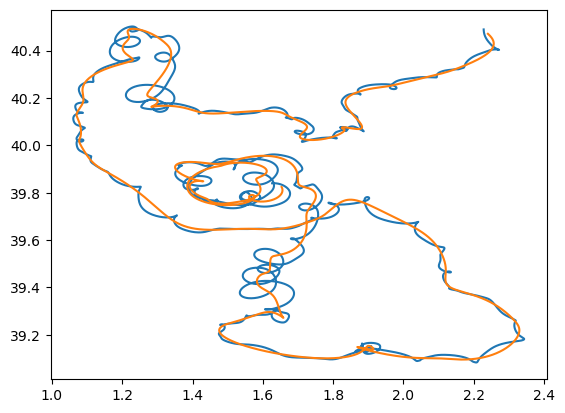

In [22]:
i=8
dsi_ = dsi.isel(drifter_id=i).dropna('datetime')
ds_ = ds.isel(drifter_id=i).dropna('datetime')

fig, ax = plt.subplots()
ax.plot(ds_.longitude, ds_.latitude)
ax.plot(dsi_.longitude, dsi_.latitude)
#ds_.plot.scatter(x='longitude', y='latitude', c='r', ax=ax)

____
# Store

In [13]:
dsi.where(ds.gap_mask==1).to_netcdf(os.path.join(zarr_dir,'before_coloc', 'low_pass_all_med_variational_10min_v0.nc'))